# Experimenting with ML Model Parameters

## 📚 Learning Objectives

By completing this notebook, you will:
- Experiment with changes in ML model parameters
- Observe changes in model fit to training data
- Understand the impact of parameter changes on model behavior
- Connect linear algebra concepts to ML model optimization

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 3, lesson 04 "Gradient Descent and Loss Functions" — you already swept the learning rate by hand there; here the same parameter changes are read through a linear-algebra lens.

**Used later in:** Course 04 (AIAT 114) — Unit 5, lesson 01 "Grid Search and Random Search" — which automates the sweep you are doing manually.

---

This notebook covers practical activities from **Course 03, Unit 1**:
- Experimenting with changes in ML model parameters and observing changes in model fit

---

## Introduction

**Model parameters** can be viewed as vectors in parameter space. Changes to these parameters directly affect how well the model fits the training data. Understanding this relationship is fundamental to machine learning optimization.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup: NumPy/Matplotlib plus sklearn's linear models (LinearRegression, Ridge, Lasso),
# the real diabetes dataset, a scaler, and metrics - the tools for the parameter experiments below.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Confirm the environment is ready before any math starts.
print("✅ Libraries imported!")
print("\nExperimenting with ML Model Parameters")
print("=" * 60)


✅ Libraries imported!

Experimenting with ML Model Parameters


---

## 🌉 Bridge: The ML Model We Use as a Black Box

This notebook experiments with a scikit-learn **LinearRegression** model — machinery that is taught properly later (loss functions and regularization in Unit 3, notebooks 02-04; how models learn in Course 04). Here we use the model **as a black box** whose learned parameters form a *vector* — the linear-algebra object this unit is about. The minimum you need to follow along:

- **Linear model**: predictions are ŷ = Xw + b — a matrix-vector product (Unit 1 material!). *Fitting* means finding the weight vector w and intercept b that make ŷ close to y.
- **MSE** (mean squared error): the average of (y − ŷ)². Lower is better; 0 is perfect.
- **R²**: the fraction of the target's variance the model explains — 1.0 is perfect, 0 means no better than always predicting the mean.
- **Train/test split**: fit on one part of the data, evaluate on a held-out part, so the score measures generalization rather than memorization.
- **Ridge alpha (Part 2)**: a penalty on large weights; bigger α shrinks the weight vector's norm ‖θ‖. Slogan level here — Unit 3, notebook 02 explains why.

**The point of this notebook**: parameters are just vectors, so we can scale them, add noise to them, and measure their norm. Everything else is previewed here and taught fully later — **Course 04 opens the black box**.

## Part 1: Linear Regression Parameter Experiments


In [2]:
# Baseline experiment: fit plain linear regression on a REAL medical dataset.
# There is no "true" weight vector to recover here - the coefficients are whatever the
# real patients' data implies, which is exactly the situation you meet in practice.

print("=" * 60)
print("Part 1: Linear Regression Parameter Experiments")
print("=" * 60)

# Real dataset: sklearn's diabetes study - 442 patients, 10 baseline measurements
# (age, sex, BMI, average blood pressure and six blood-serum readings). The target is
# a quantitative measure of disease progression one year after baseline.
diabetes = load_diabetes()
X_all, y = diabetes.data, diabetes.target
param_names = list(diabetes.feature_names)

print(f"\nDataset: diabetes progression - {X_all.shape[0]} patients, {X_all.shape[1]} features")
print(f"Features: {param_names}")
print(f"Target range: {y.min():.0f} to {y.max():.0f} (disease progression score)")

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=42)

# Standardize the features so every coefficient is measured on the same footing.
# This matters for Part 2: a regularization penalty on ||theta|| is only fair if the
# features share a scale.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

# Train baseline model
model_baseline = LinearRegression()
model_baseline.fit(X_train, y_train)

print("\nBaseline Model Parameters (weights) - one per feature:")
for name, w in zip(param_names, model_baseline.coef_):
    print(f"  {name:>4}: {w:8.3f}")
print(f"Intercept: {model_baseline.intercept_:.4f}")
print(f"Parameter vector norm ||theta||: {np.linalg.norm(model_baseline.coef_):.4f}")

# Evaluate
y_pred_baseline = model_baseline.predict(X_test)
mse_baseline = mean_squared_error(y_test, y_pred_baseline)
r2_baseline = r2_score(y_test, y_pred_baseline)

print("\nBaseline Performance:")
print(f"MSE: {mse_baseline:.4f}")
print(f"R²: {r2_baseline:.4f}")


Part 1: Linear Regression Parameter Experiments

Dataset: diabetes progression - 442 patients, 10 features
Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Target range: 25 to 346 (disease progression score)

Training samples: 353
Test samples: 89

Baseline Model Parameters (weights) - one per feature:
   age:    1.754
   sex:  -11.512
   bmi:   25.607
    bp:   16.829
    s1:  -44.449
    s2:   24.641
    s3:    7.677
    s4:   13.139
    s5:   35.161
    s6:    2.351
Intercept: 153.7365
Parameter vector norm ||theta||: 71.6297

Baseline Performance:
MSE: 2900.1936
R²: 0.4526


In [3]:
# Experiment: Modify parameters manually.
# The parameter vector is just a vector, so we can halve it, stretch it, or jitter it and
# measure what each edit costs. The random jitter here is deliberate noise INJECTED into a
# real fitted model - the randomness is the experiment, not the data.

print("\n" + "=" * 60)
print("Experiment: Modifying Parameters Manually")
print("=" * 60)

baseline_params = np.concatenate([model_baseline.coef_, [model_baseline.intercept_]])

# Create modified models with different parameter vectors
rng = np.random.default_rng(42)  # seeded so the jitter is reproducible
params_scaled_05 = baseline_params * 0.5
params_scaled_15 = baseline_params * 1.5
# Jitter scaled to the size of the weights themselves (real coefficients here are ~1-60)
params_noise = baseline_params + 0.1 * np.linalg.norm(baseline_params) * rng.normal(size=len(baseline_params))


def evaluate_params(X, y, params):
    """Evaluate model with given parameters"""
    coef = params[:-1]
    intercept = params[-1]
    y_pred = X @ coef + intercept
    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    return mse, r2


print("\nParameter Modifications (evaluated on the held-out test patients):")
for name, params in [("Baseline", baseline_params),
                      ("Scaled 0.5x", params_scaled_05),
                      ("Scaled 1.5x", params_scaled_15),
                      ("With noise", params_noise)]:
    mse, r2 = evaluate_params(X_test, y_test, params)
    print(f"\n{name}:")
    print(f"  ||theta|| = {np.linalg.norm(params[:-1]):.3f}, intercept = {params[-1]:.2f}")
    print(f"  MSE: {mse:.4f}, R²: {r2:.4f}")

print("\nRead the table: every edit to the fitted vector makes the model worse on real")
print("patients. That is what 'the model was optimized' actually means.")



Experiment: Modifying Parameters Manually

Parameter Modifications (evaluated on the held-out test patients):

Baseline:
  ||theta|| = 71.630, intercept = 153.74
  MSE: 2900.1936, R²: 0.4526

Scaled 0.5x:
  ||theta|| = 35.815, intercept = 76.87
  MSE: 8963.0613, R²: -0.6917

Scaled 1.5x:
  ||theta|| = 107.445, intercept = 230.60
  MSE: 8359.9812, R²: -0.5779

With noise:
  ||theta|| = 104.792, intercept = 168.65
  MSE: 7505.4484, R²: -0.4166

Read the table: every edit to the fitted vector makes the model worse on real
patients. That is what 'the model was optimized' actually means.


## Part 2: Regularization Parameter Experiments



Part 2: Regularization Parameter Experiments

Regularization Effects on Parameters:
  Alpha  0.001: MSE=2900.1817, R²=0.4526, ||θ||=71.6150
  Alpha  0.010: MSE=2900.0751, R²=0.4526, ||θ||=71.4836
  Alpha  0.100: MSE=2899.0546, R²=0.4528, ||θ||=70.2143
  Alpha  1.000: MSE=2892.0146, R²=0.4541, ||θ||=60.9088
  Alpha 10.000: MSE=2875.7787, R²=0.4572, ||θ||=43.0280
  Alpha 100.000: MSE=2858.2243, R²=0.4605, ||θ||=34.2828


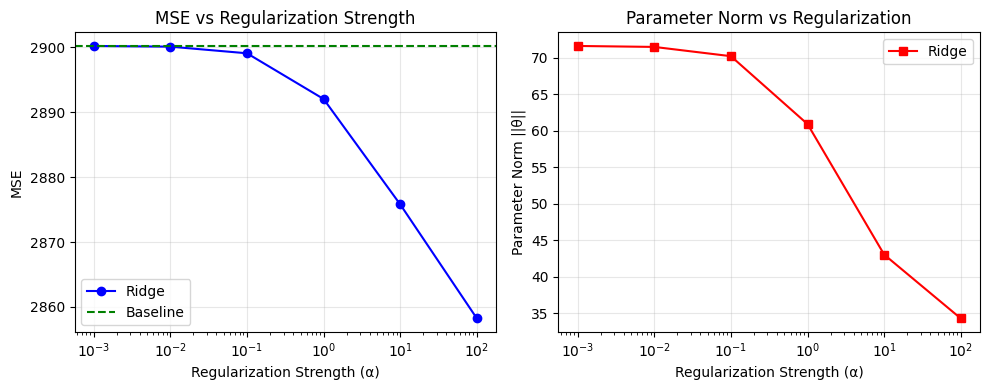


✅ Regularization parameter effects visualized!


In [4]:
# Sweep the Ridge regularization strength alpha across five orders of magnitude.
# Watch the trade-off: larger alpha shrinks the parameter norm ||θ|| while test error shifts.

print("\n" + "=" * 60)
print("Part 2: Regularization Parameter Experiments")
print("=" * 60)

# Experiment with different regularization strengths
alpha_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

# Train one Ridge model per alpha and record error and coefficient size.
ridge_results = []
for alpha in alpha_values:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    ridge_pred = ridge.predict(X_test)
    mse = mean_squared_error(y_test, ridge_pred)
    r2 = r2_score(y_test, ridge_pred)
    param_norm = np.linalg.norm(ridge.coef_)
    ridge_results.append({'alpha': alpha, 'mse': mse, 'r2': r2, 'param_norm': param_norm})

print("\nRegularization Effects on Parameters:")
for r in ridge_results:
    print(f"  Alpha {r['alpha']:6.3f}: MSE={r['mse']:.4f}, R²={r['r2']:.4f}, ||θ||={r['param_norm']:.4f}")

# Visualize
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
alphas = [r['alpha'] for r in ridge_results]
mses = [r['mse'] for r in ridge_results]
plt.semilogx(alphas, mses, 'b-o', label='Ridge')
plt.axhline(y=mse_baseline, color='g', linestyle='--', label='Baseline')
plt.xlabel('Regularization Strength (α)')
plt.ylabel('MSE')
plt.title('MSE vs Regularization Strength')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
norms = [r['param_norm'] for r in ridge_results]
plt.semilogx(alphas, norms, 'r-s', label='Ridge')
plt.xlabel('Regularization Strength (α)')
plt.ylabel('Parameter Norm ||θ||')
plt.title('Parameter Norm vs Regularization')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Regularization parameter effects visualized!")

## Summary

### Key Concepts:
1. **Parameters as Vectors**: Model parameters can be viewed as vectors in parameter space
2. **Parameter Space**: Different parameter values create different model fits
3. **Regularization**: Constrains parameter values to prevent overfitting
4. **Optimization**: Finding optimal parameters minimizes the loss

### Best Practices:
- Visualize parameter space to understand model behavior
- Experiment with different parameter values to see their effects
- Use regularization to constrain parameter space
- Monitor both training and test performance

### Applications:
- Model optimization
- Hyperparameter tuning
- Understanding model behavior
- Regularization selection

**Reference:** Course 03, Unit 1: "Linear Algebra for Machine Learning" - Experimenting with ML model parameters practical content

## 📚 References

1. Hoerl, A. E., & Kennard, R. W. (1970). *Ridge Regression: Biased Estimation for Nonorthogonal Problems*. Technometrics, 12(1), 55–67.
2. Tibshirani, R. (1996). *Regression Shrinkage and Selection via the Lasso*. Journal of the Royal Statistical Society, Series B, 58(1), 267–288.
3. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed.), Ch. 6: Linear Model Selection and Regularization. Springer. <https://www.statlearning.com/>